Import the libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
from scipy.special import hermitenorm

Define the value of the inner width of the fully connected neural network (we assume all the inner widths to be equal to $n$) and the number of iteration that we are going to do into the Monte Carlo algorithm to estimate the value of a neural network at $x^{(1)}=1$ (assuming that the neural network $z^{(2)}:\mathbb{R}\to\mathbb{R}$).


In [2]:
#n_0=1
#x^{(1)}=1
n_1=20 # width used to compare the NN and its infinite-width Gaussian limit
n_2=20 # width used to compare the NN and its para_gaussian_1
n_3=20 # width used to compare the NN and its para_gaussian_2
n_4 = 1000 # width used to compare the NN and its para_gaussian_3
N = 2**18 # Number iteration Monte Carlo
rng = np.random.default_rng(0) # Creates a generator of random numbers of NumPy with fixed seed equal to 0.

Define the ReLu activation function under the critical parametrization $C_b=0$ (which is the variance of the bias) and $C_W=\sqrt{2}$ (which is the variance of the weights):
$\operatorname{ReLU}(x)=\sqrt{2}\max\{0,x\}$.

In [3]:
def phi(x):
    return np.sqrt(2.0) * np.maximum(x, 0.0)

We do the Monte Carlo simulation to compute the value of a fully connected neural network evaluated in $x_0=1$ with depth $L=1$ and inner width $n_1=n$:

$z_1^{(2)}(1) =\frac{1}{\sqrt{n_1}}\sum_{j=1}^{n_1}W^{(2)}_{1,j}\operatorname{ReLU}(z_j^{(1)}(1))$,

where

$z_j^{(1)}(1)=W^{(1)}_{j,1}$

and $W_{i,j}^{(\ell)}\sim\mathcal{N}(0,1)$ for every $\ell=1,2$, $i=1,\dots,n_{\ell}$ and $j=1,\dots,n_{\ell-1}$.

We then approximate the density of the neural network $z^{(2)}(1)$ using the KDE function andompute the values of the approximated density of the neural network in the inputs $x$.


In [4]:
def nn_output(n,N,x):
 rng = np.random.default_rng(0)
 z_1 = rng.standard_normal(size=(N, n))
 W= rng.standard_normal(size=(N, n))
 z = np.sum(W * phi(z_1), axis=1) / np.sqrt(n)
 kde = gaussian_kde(z)
 z_mc = kde(x)
 return z_mc

Compute the Hermite polynomials of degree $4,6$ and $8$.

In [5]:
H4=hermitenorm(4) #x**4 - 6*(x**2) + 3

H6 = hermitenorm(6) #x**6 - 15*(x**4) + 45*(x**2) - 15

H8 = hermitenorm(8) #x**8 - 28*(x**6) + 210*(x**4) - 420*(x**2) + 105

Do a grid of $1000$ points where to compute the density of the neural network, of its Gaussian limit (for $n\to\infty$) and of the Edgeworth expansions of different orders (also called para-Gaussians in Nica and Ortmann (2024)).


In [6]:
x = np.linspace(-4, 4, 1000)

Compute the values of the approximated density of the neural network in the inputs $x$.


In [7]:
z_prime_1 = nn_output(n_1,N,x)
z_prime_2 = nn_output(n_2,N,x)
z_prime_3 = nn_output(n_3,N,x)
z_prime_4 = nn_output(n_4,N,x)

Compute the values of the standard density in the inputs $x$. Note that the limiting Gaussian random variable $G^{(2)}(1)$ is a standard Gaussian since its variance is
$K^{(2)}=C_W\mathbb{E}\left[(G^{(1)}(1))^21_{\{G^{(1)}(1)>0\}}\right]=\frac{C_W}{2}\mathbb{E}[(G^{(1)}{(1)})^2]=\frac{C_W}{2}K^{(1)}=\frac{C_W^2}{2}=1$.

In [8]:
rho_gauss = norm.pdf(x)

We now compute the following Edgeworth expansions (Para-Gaussians) for the neural network:
*   $
y\mapsto \phi_{K^{(2)}}(y)\left(1+\frac{5}{8n_1}H_4\left(\frac{y}{\sqrt{K^{(2)}}}\right)\right),$

*   $y\mapsto \phi_{K^{(2)}}(y)\left(1+\frac{5}{8n_1}H_4\left(\frac{y}{\sqrt{K^{(2)}}}\right)+\frac{11}{12n_1^2}H_6\left(\frac{y}{\sqrt{K^{(2)}}}\right)\right),$


*   $y\mapsto \phi_{K^{(2)}}(y)\left(1+\frac{5}{8n_1}H_4\left(\frac{y}{\sqrt{K^{(2)}}}\right)+\frac{11}{12n_1^2}H_6\left(\frac{y}{\sqrt{K^{(2)}}}\right)+\left(\frac{1573}{192n_1^2}
+\frac{25(n_1-1)}{64n_1^2}\right)H_8\left(\frac{y}{\sqrt{K^{(2)}}}\right)\right).$

We obtained this densities observing that under our assumptions

*   $\mathbb{E}\left[(A^{(2)}-\mathbb{E}[A^{(2)}])^2\right]=\frac{5}{n_1},$
*   $\mathbb{E}\left[(A^{(2)}-\mathbb{E}[A^{(2)}])^3\right]=
\frac{44}{n_1^2},$


*   $\mathbb{E}\left[(A^{(2)}-\mathbb{E}[A^{(2)}])^4\right]=\frac{1573}{n_1^2}
+\frac{75(n_1-1)}{n_1^2}$,

 where

 $A^{(2)}:=C_W(z^{(1)}(1))^21_{\{z^{(1)}>0\}}$,

  and that in general the Egdeworth density in the case of a neural network $z^{(2)}:\mathbb{R}\to\mathbb{R}$ is given by

$
\gamma_{z^{(2)},G^{(2)},m}(x)
=\phi_{K^{(2)}}({x})
+\sum_{k=1}^{2m-1}\frac{1}{k!\,2^k}
\mathbb{E}\!\left[Q^{2k}\right]
H_{2k}\!\left(\sqrt{K^{(2)}})^{-1}{x}\right)
\phi_{K^{(2)}}\!\left({x}\right),\quad{\text{for every $x\in\mathbb{R}$}},
$

with

$
Q:=(\sqrt{K^{(2)}})^{-1}(A^{(2)}-K^{(2)})(\sqrt{K^{(2)}})^{-1}.
$


In [9]:
# First Para-Gaussian
def para_gaussian_1(n,x):
  corr_H4= 1+(5 / (8*(n))) * H4(x)
  return rho_gauss * corr_H4
rho_para_1 = para_gaussian_1(n_2,x)

# Second Para-Gaussian
def para_gaussian_2(n,x):
  corr_H6=11/ (12*((n)**2)) * H6(x)
  return para_gaussian_1(n,x)+rho_gauss * corr_H6
rho_para_2=para_gaussian_2(n_3,x)

# Third Para-Gaussian
def para_gaussian_3(n,x):
  corr_H8=(1573 / (198*(n)**2) + 25/(128*(n))) * H8(x)
  return para_gaussian_2(n,x)+rho_gauss * corr_H8
rho_para_3=para_gaussian_3(n_4,x)

We compute the signed pointwise error between the neural network and its Edgeworth expansions.

In [10]:
def pointwise_error_nn(rho_approx,n,x):
    return nn_output(n,N,x) - rho_approx

We now plot a figure where we compare the density of the neural network with the density of the limiting Gaussian random variable and with the first three Para-Gaussians.

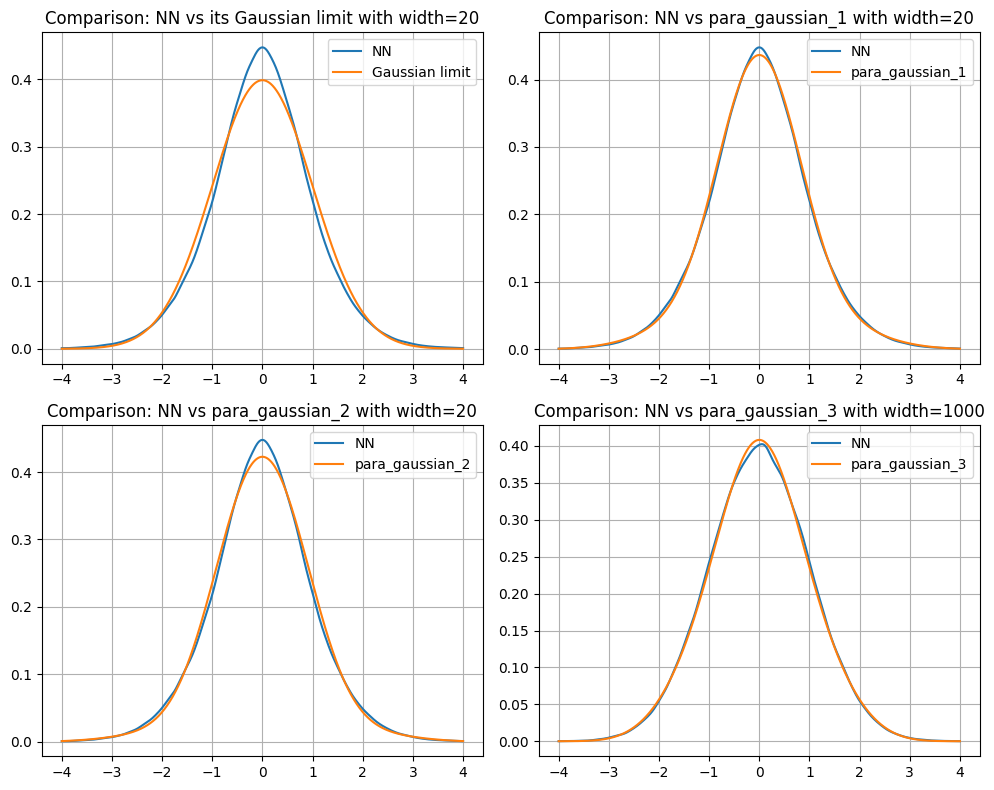

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax=axes.flat[0]
ax.plot(x, z_prime_1, label='NN')
ax.plot(x, rho_gauss, label='Gaussian limit')
ax.set_title(f'Comparison: NN vs its Gaussian limit with width={n_1}')
ax.legend()
ax.grid(True)

ax=axes.flat[1]
ax.plot(x, z_prime_2, label='NN')
ax.plot(x, rho_para_1, label='para_gaussian_1')
ax.set_title(f'Comparison: NN vs para_gaussian_1 with width={n_2}')
ax.legend()
ax.grid(True)

ax=axes.flat[2]
ax.plot(x,z_prime_3, label='NN')
ax.plot(x, rho_para_2, label='para_gaussian_2')
ax.set_title(f'Comparison: NN vs para_gaussian_2 with width={n_3}')
ax.legend()
ax.grid(True)

ax=axes.flat[3]
ax.plot(x, z_prime_4, label='NN')
ax.plot(x, rho_para_3, label='para_gaussian_3')
ax.set_title(f'Comparison: NN vs para_gaussian_3 with width={n_4}')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In this second step we compare the signed pointwise error between the neural network and the approximations already mentioned for different values of inner width.


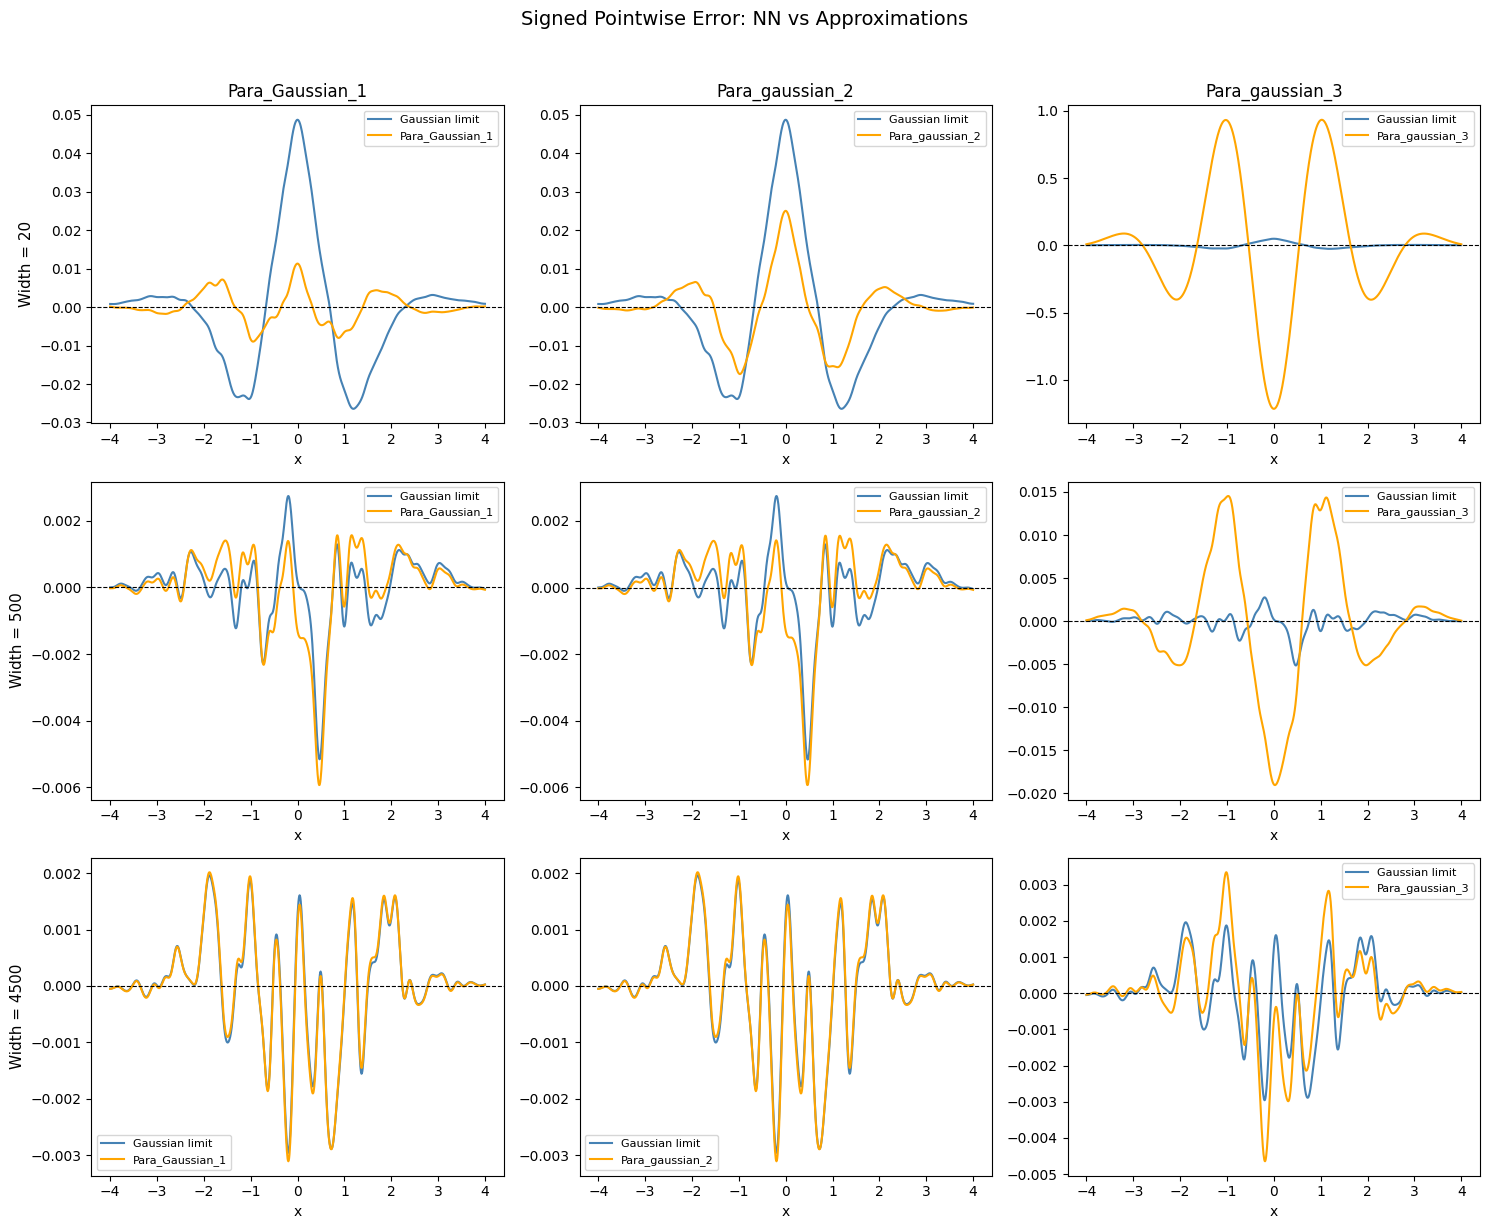

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

inner_widths = [20, 500, 4500]
approximation_names = ["Para_Gaussian_1", "Para_gaussian_2", "Para_gaussian_3"]

for i, width in enumerate(inner_widths):
    rho_para_1 = para_gaussian_1(width, x)
    rho_para_2 = para_gaussian_2(width, x)
    rho_para_3 = para_gaussian_3(width, x)
    err_para_1 = pointwise_error_nn(rho_para_1, width, x)
    err_para_2 = pointwise_error_nn(rho_para_2, width, x)
    err_para_3 = pointwise_error_nn(rho_para_3, width, x)
    errors = [err_para_1, err_para_2, err_para_3]

    for j, approx_name in enumerate(approximation_names):
        ax = axes[i, j]

        error_1 = pointwise_error_nn(rho_gauss, width, x)
        error_2 = errors[j]

        ax.plot(x, error_1, color="steelblue", label="Gaussian limit")
        ax.plot(x, error_2, color="orange", label=approx_name)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

        if i == 0:
            ax.set_title(approx_name, fontsize=12)
        if j == 0:
            ax.set_ylabel(f"Width = {width}", fontsize=11)

        ax.set_xlabel("x")
        ax.legend(fontsize=8)

fig.suptitle("Signed Pointwise Error: NN vs Approximations", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pointwise_error.pdf", bbox_inches="tight")
plt.show()


## Comment:

We see that the Edgeworth expansion in general provides a better approximation than the infinite-width Gaussian limit in the case when the sum over $k$ in the definition of $\gamma_{z^{(2)},G^{(2)},m}$ arrives to $k=2$ and $k=3$ (mostly for low inner width). In the case when the sum over $k$ stops at $k=4$ we see that the Edgeworth expansion gives a worse approximation than the others for lower width. This is due to the fact that in this case the oscillatory behavior of higher-order Hermite polynomials in the expansion predominate. These deviations are consistent with the known limitations of Edgeworth expansions at moderate sample sizes.

## References:



*   L. Celli. Optimal Non-Asymptotic Edgeworth Expansions for Multivariate Neural Network Outputs. *In preparation*.
*   M. Nica and J. Ortmann. Improving the gaussian approximation in neural networks: Para-gaussians and edgeworth expansions. In *NeurIPS 2024 Workshop on Mathematics of Modern Machine Learning*, 2024.
